# Milestone 5 — Paged KV cache

Fixed-size KV **blocks** + a **block table**. Same memory budget: **reserved**
(worst-case at admit) vs **paged** (grow as tokens are produced).

In [1]:
!git clone https://github.com/Jayaprakash-030/tiny-inference-engine.git
%cd tiny-inference-engine
!pip install -q -e .

Cloning into 'tiny-inference-engine'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 122 (delta 70), reused 87 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 240.89 KiB | 24.09 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/tiny-inference-engine
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiny-inference-engine (pyproject.toml) ... done


In [2]:
from engine import load
from engine.paged import (
    check_paged_matches_cached,
    compare_block_budget,
    sweep_block_budget,
)
from engine.results import save

rt = load()
rt.describe()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model : Qwen/Qwen3-0.6B
device: cuda
dtype : torch.float16
layers: 28
gpu   : Tesla T4


### Correctness

In [3]:
assert check_paged_matches_cached(rt)

paged run_one matches cached: True


### Reserved vs paged under one budget, then sweep + save

Tight budgets (e.g. `n_blocks=16`) can admit more than they can grow: paged mode **preempts** mid-decode (`oom_grow`) instead of crashing.


In [4]:
reserved, paged = compare_block_budget(
    rt, n_blocks=32, n_requests=16, max_new_tokens=64,
)
save([reserved, paged])

budget: 32 blocks × 16 tokens = 512 token-slots
  id  arrival_ms  limit  prompt
   0         0.0     44  'The capital of France is'
   1        41.4     60  'Explain how a GPU executes a matrix multiplicati'
   2       217.6     24  'In 2026, the most important trend in machine lea'
   3       338.0      8  'def fibonacci(n):'
   4       374.1     40  'The three laws of thermodynamics are'
   5       674.7     12  'A transformer model processes text by'
   6      1182.5     16  'The difference between a CPU and a GPU is'
   7      1390.2     48  'Once upon a time in a small village'
   8      1680.7     56  'The capital of France is'
   9      1727.2     32  'Explain how a GPU executes a matrix multiplicati'
  10      1890.7     36  'In 2026, the most important trend in machine lea'
  11      2177.1     20  'def fibonacci(n):'
  12      2321.1      4  'The three laws of thermodynamics are'
  13      2401.0     28  'A transformer model processes text by'
  14      2414.3     64  'The di

In [5]:
# Includes n_blocks=16 — expect some paged oom_grow preempts, not a crash.
m5 = sweep_block_budget(
    rt,
    block_budgets=(16, 32, 48, 64),
    n_requests=16,
    max_new_tokens=64,
)
save(m5)


budget: 16 blocks × 16 tokens = 256 token-slots
  id  arrival_ms  limit  prompt
   0         0.0     44  'The capital of France is'
   1        41.4     60  'Explain how a GPU executes a matrix multiplicati'
   2       217.6     24  'In 2026, the most important trend in machine lea'
   3       338.0      8  'def fibonacci(n):'
   4       374.1     40  'The three laws of thermodynamics are'
   5       674.7     12  'A transformer model processes text by'
   6      1182.5     16  'The difference between a CPU and a GPU is'
   7      1390.2     48  'Once upon a time in a small village'
   8      1680.7     56  'The capital of France is'
   9      1727.2     32  'Explain how a GPU executes a matrix multiplicati'
  10      1890.7     36  'In 2026, the most important trend in machine lea'
  11      2177.1     20  'def fibonacci(n):'
  12      2321.1      4  'The three laws of thermodynamics are'
  13      2401.0     28  'A transformer model processes text by'
  14      2414.3     64  'The di

### Plot completed / rejected / peak concurrent

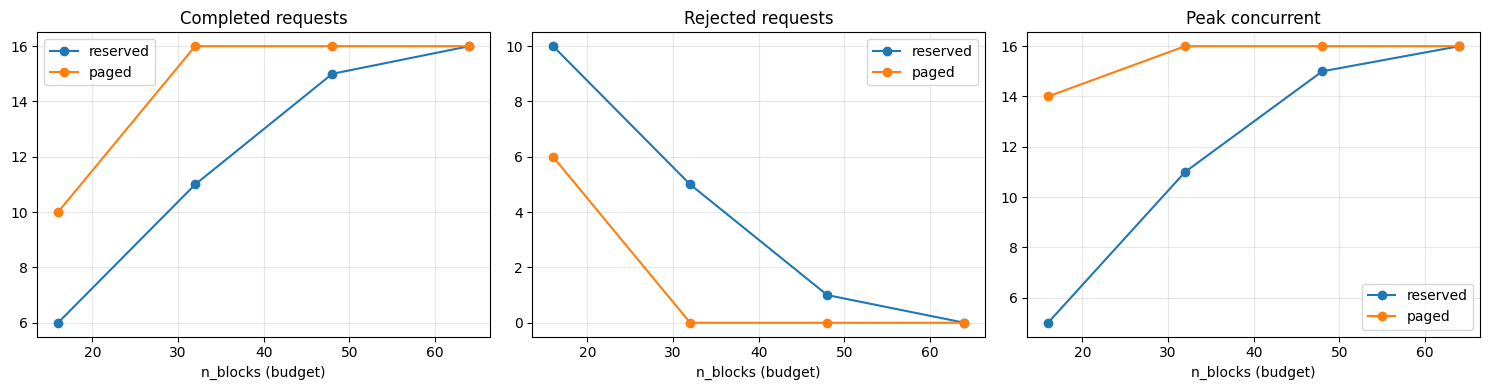

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("benchmarks/plots").mkdir(parents=True, exist_ok=True)

reserved_rows = [r for r in m5 if r["mode"] == "reserved"]
paged_rows = [r for r in m5 if r["mode"] == "paged"]
budgets = [r["n_blocks"] for r in reserved_rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], "completed", "Completed requests"),
    (axes[1], "rejected", "Rejected requests"),
    (axes[2], "peak_concurrent", "Peak concurrent"),
]:
    ax.plot(budgets, [r[key] for r in reserved_rows], marker="o", label="reserved")
    ax.plot(budgets, [r[key] for r in paged_rows], marker="o", label="paged")
    ax.set_title(title)
    ax.set_xlabel("n_blocks (budget)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("benchmarks/plots/m5_paged_kv.png", dpi=140)
plt.show()